# Truth-free next-step selection rules for repeated symmetric cross-fit outputs

This notebook performs **post-processing / reselection** on the **already generated** formal repeated symmetric cross-fit results.

It does **not** retrain SVGP models and does **not** rerun the full `R=100, B=100` experiment.

## Core principle

Selection must remain **truth-free**:

- do **not** use `true_f`
- do **not** use final deployed hit
- do **not** use any ground-truth-based quantity in calibration / reselection

Only the following objects are used for reselection:

- calibration bank indicators
- pseudo-truth
- directional coverage surfaces
- deploy alpha-bank (`mu/std/lower/upper`)

If `deploy_final_rep*.csv` contains `true_f`, it is used **only for offline evaluation after selection**.


In [1]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

try:
    from scipy.stats import t as student_t
except Exception:
    student_t = None


## 1. User settings

In [2]:
# ------------------------------------------------------------------
# User paths
# ------------------------------------------------------------------
ROOT = Path(r"C:\Users\yangy\26 spring\with reference\more_cross")
OUT_DIR = ROOT / "truthfree_nextstep_notebook"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# strategies to run
STRATEGIES = [
    "baseline_replay",
    "lcb_direction",
    "proxy_corrected",
    "smooth_proxy_dp",
    # "robust_cvar",
]

# nominal coverage target
NOMINAL = 0.95

# parameters
LCB_DELTA = 0.05
PROXY_LAMBDA = 1.0
PROXY_TAU = None          # e.g. 0.02
ROBUST_Q = 0.2
SMOOTH_PROXY_LAMBDA = 1.0
SMOOTH_PENALTY = 0.2
SMOOTH_INSTABILITY_PENALTY = 0.0
FALLBACK = "closest"      # or "largest"

print("ROOT   =", ROOT)
print("OUT_DIR=", OUT_DIR)
print("STRATEGIES =", STRATEGIES)


ROOT   = C:\Users\yangy\26 spring\with reference\more_cross
OUT_DIR= C:\Users\yangy\26 spring\with reference\more_cross\truthfree_nextstep_notebook
STRATEGIES = ['baseline_replay', 'lcb_direction', 'proxy_corrected', 'smooth_proxy_dp']


## 2. Data loading helpers

In [3]:
REP_RE = re.compile(r"rep(\d+)")

@dataclass
class RepData:
    rep_id: int
    rep_dir: Path
    x: np.ndarray
    alphas: np.ndarray
    deploy_mu: np.ndarray
    deploy_std: np.ndarray
    deploy_lower: np.ndarray
    deploy_upper: np.ndarray
    calib_mu: np.ndarray
    calib_std: np.ndarray
    calib_lower: np.ndarray
    calib_upper: np.ndarray
    pseudo_truth: np.ndarray
    calib_indicators: np.ndarray
    directional_cov: np.ndarray
    baseline_alpha_star: np.ndarray
    deploy_final_df: Optional[pd.DataFrame] = None


def parse_rep_id(path: Path) -> int:
    match = REP_RE.search(path.name)
    if match is None:
        raise ValueError(f"Could not parse rep id from: {path}")
    return int(match.group(1))


def find_single(rep_dir: Path, pattern: str, required: bool = True) -> Optional[Path]:
    matches = list(rep_dir.glob(pattern))
    if len(matches) == 1:
        return matches[0]
    if len(matches) == 0 and not required:
        return None
    raise FileNotFoundError(f"Expected exactly one match for {pattern} in {rep_dir}, got {len(matches)}")


def load_rep(rep_dir: Path) -> RepData:
    rep_id = parse_rep_id(rep_dir)

    deploy_bank_path = find_single(rep_dir, "deploy_full_by_alpha_rep*_A*_J*.npz")
    calib_bank_path = find_single(rep_dir, "calib_crossfit_interval_bank_rep*_S*_A*_B*_J*.npz")
    directional_cov_path = find_single(rep_dir, "directional_coverage_rep*_S*_A*_J*.npy")
    alpha_star_path = find_single(rep_dir, "alpha_star_curve_rep*.csv")
    deploy_final_path = find_single(rep_dir, "deploy_final_rep*_J*.csv", required=False)

    deploy_bank = np.load(deploy_bank_path)
    calib_bank = np.load(calib_bank_path)

    x = np.array(deploy_bank["x"], dtype=float)
    alphas = np.array(deploy_bank["alphas"], dtype=float)
    deploy_mu = np.array(deploy_bank["mu"], dtype=float)
    deploy_std = np.array(deploy_bank["std"], dtype=float)
    deploy_lower = np.array(deploy_bank["lower"], dtype=float)
    deploy_upper = np.array(deploy_bank["upper"], dtype=float)

    calib_mu = np.array(calib_bank["mu"], dtype=float)
    calib_std = np.array(calib_bank["std"], dtype=float)
    calib_lower = np.array(calib_bank["lower"], dtype=float)
    calib_upper = np.array(calib_bank["upper"], dtype=float)
    pseudo_truth = np.array(calib_bank["pseudo_truth"], dtype=float)
    calib_indicators = np.array(calib_bank["indicators"], dtype=float)

    directional_cov = np.array(np.load(directional_cov_path), dtype=float)
    baseline_df = pd.read_csv(alpha_star_path).sort_values("x").reset_index(drop=True)
    baseline_alpha_star = baseline_df["alpha_star"].to_numpy(dtype=float)

    if not np.allclose(baseline_df["x"].to_numpy(dtype=float), x):
        raise ValueError(f"x-grid mismatch in alpha_star_curve for rep {rep_id}")
    if directional_cov.shape != pseudo_truth.shape:
        raise ValueError(f"directional_coverage shape mismatch in rep {rep_id}")

    deploy_final_df = None
    if deploy_final_path is not None:
        deploy_final_df = pd.read_csv(deploy_final_path).sort_values("x").reset_index(drop=True)
        if not np.allclose(deploy_final_df["x"].to_numpy(dtype=float), x):
            raise ValueError(f"x-grid mismatch in deploy_final for rep {rep_id}")

    return RepData(
        rep_id=rep_id,
        rep_dir=rep_dir,
        x=x,
        alphas=alphas,
        deploy_mu=deploy_mu,
        deploy_std=deploy_std,
        deploy_lower=deploy_lower,
        deploy_upper=deploy_upper,
        calib_mu=calib_mu,
        calib_std=calib_std,
        calib_lower=calib_lower,
        calib_upper=calib_upper,
        pseudo_truth=pseudo_truth,
        calib_indicators=calib_indicators,
        directional_cov=directional_cov,
        baseline_alpha_star=baseline_alpha_star,
        deploy_final_df=deploy_final_df,
    )


def validate_shared_layout(reps: Sequence[RepData]) -> None:
    x0 = reps[0].x
    a0 = reps[0].alphas
    for rep in reps[1:]:
        if not np.allclose(rep.x, x0):
            raise ValueError(f"x-grid mismatch at rep {rep.rep_id}")
        if not np.allclose(rep.alphas, a0):
            raise ValueError(f"alpha-grid mismatch at rep {rep.rep_id}")


def discover_reps(root: Path) -> List[RepData]:
    rep_dirs = sorted(
        [p for p in root.iterdir() if p.is_dir() and REP_RE.search(p.name)],
        key=parse_rep_id
    )
    if not rep_dirs:
        raise FileNotFoundError(f"No repXXX folders found in {root}")
    reps = [load_rep(p) for p in rep_dirs]
    validate_shared_layout(reps)
    return reps


## 3. Truth-free diagnostic objects

In [4]:
def t_critical_one_sided(df: int, level: float) -> float:
    if student_t is not None:
        return float(student_t.ppf(level, df))
    return 1.833  # approx for df=9, one-sided 95%


def alpha_to_idx(alpha_grid: np.ndarray, alpha_values: np.ndarray) -> np.ndarray:
    alpha_values = np.asarray(alpha_values, dtype=float)
    idx = np.argmin(np.abs(alpha_values[:, None] - alpha_grid[None, :]), axis=1)
    return idx


def compute_truthfree_objects(rep: RepData, eps: float = 1e-12) -> Dict[str, np.ndarray]:
    S, A, B, J = rep.calib_indicators.shape

    calib_cov_dir = rep.calib_indicators.mean(axis=2)        # [S, A, J]
    calib_cov_cf = calib_cov_dir.mean(axis=0)                # [A, J]

    dep_hit_pseudo = (
        (rep.pseudo_truth >= rep.deploy_lower[None, :, :]) &
        (rep.pseudo_truth <= rep.deploy_upper[None, :, :])
    ).astype(float)                                          # [S, A, J]
    dep_cov_pseudo = dep_hit_pseudo.mean(axis=0)             # [A, J]
    g_pseudo = dep_cov_pseudo - calib_cov_cf                 # [A, J]

    calib_width = rep.calib_upper - rep.calib_lower          # [S, A, B, J]
    calib_width_mean = calib_width.mean(axis=(0, 2))         # [A, J]
    deploy_width = rep.deploy_upper - rep.deploy_lower       # [A, J]
    width_ratio = deploy_width / np.maximum(calib_width_mean, eps)

    calib_mu_mean = rep.calib_mu.mean(axis=(0, 2))           # [A, J]
    calib_std_mean = rep.calib_std.mean(axis=(0, 2))         # [A, J]
    center_shift = np.abs(rep.deploy_mu - calib_mu_mean) / np.maximum(calib_std_mean, eps)
    scale_shift = np.log(np.maximum(rep.deploy_std, eps) / np.maximum(calib_std_mean, eps))

    dep_pseudo_z = (rep.pseudo_truth - rep.deploy_mu[None, :, :]) / np.maximum(rep.deploy_std[None, :, :], eps)
    dep_pseudo_z_mean_abs = np.mean(np.abs(dep_pseudo_z), axis=0)      # [A, J]

    dir_sd = np.std(calib_cov_dir, axis=0, ddof=1 if S > 1 else 0)     # [A, J]
    pseudo_hetero = np.std(rep.pseudo_truth, axis=0, ddof=1 if S > 1 else 0)   # [A, J]

    return {
        "calib_cov_dir": calib_cov_dir,
        "calib_cov_cf": calib_cov_cf,
        "dep_cov_pseudo": dep_cov_pseudo,
        "g_pseudo": g_pseudo,
        "width_ratio": width_ratio,
        "center_shift": center_shift,
        "scale_shift": scale_shift,
        "dep_pseudo_z_mean_abs": dep_pseudo_z_mean_abs,
        "dir_sd": dir_sd,
        "pseudo_hetero": pseudo_hetero,
    }


## 4. Truth-free selection rules

In [5]:
def choose_baseline(rep: RepData) -> np.ndarray:
    return alpha_to_idx(rep.alphas, rep.baseline_alpha_star)


def choose_lcb_direction(rep: RepData, tf: Dict[str, np.ndarray], nominal: float, delta: float, fallback: str) -> np.ndarray:
    cov_dir = tf["calib_cov_dir"]   # [S, A, J]
    S, A, J = cov_dir.shape
    tcrit = t_critical_one_sided(S - 1, 1.0 - delta) if S > 1 else 0.0
    alpha_idx = np.zeros(J, dtype=int)

    for j in range(J):
        mat = cov_dir[:, :, j]
        cbar = mat.mean(axis=0)
        csd = mat.std(axis=0, ddof=1 if S > 1 else 0)
        lcb = cbar - tcrit * csd / max(math.sqrt(S), 1.0)

        ok = np.where(lcb >= nominal)[0]
        if len(ok) > 0:
            alpha_idx[j] = ok[-1]
        else:
            if fallback == "closest":
                alpha_idx[j] = int(np.argmin(np.abs(cbar - nominal)))
            else:
                alpha_idx[j] = A - 1

    return alpha_idx


def choose_robust_cvar(rep: RepData, tf: Dict[str, np.ndarray], nominal: float, q: float, fallback: str) -> np.ndarray:
    cov_dir = tf["calib_cov_dir"]   # [S, A, J]
    S, A, J = cov_dir.shape
    alpha_idx = np.zeros(J, dtype=int)
    worst_count = max(1, int(math.ceil(q * S)))

    for j in range(J):
        score = np.zeros(A, dtype=float)
        for a in range(A):
            vals = np.sort(cov_dir[:, a, j])
            score[a] = vals[:worst_count].mean()

        ok = np.where(score >= nominal)[0]
        if len(ok) > 0:
            alpha_idx[j] = ok[-1]
        else:
            if fallback == "closest":
                alpha_idx[j] = int(np.argmin(np.abs(score - nominal)))
            else:
                alpha_idx[j] = A - 1

    return alpha_idx


def choose_proxy_corrected(rep: RepData, tf: Dict[str, np.ndarray], nominal: float, lam: float, tau: Optional[float], fallback: str) -> np.ndarray:
    cov = tf["calib_cov_cf"]        # [A, J]
    g = tf["g_pseudo"]              # [A, J]
    A, J = cov.shape
    alpha_idx = np.zeros(J, dtype=int)

    for j in range(J):
        corrected = cov[:, j] + lam * g[:, j]
        stable = np.where(g[:, j] >= -tau)[0] if tau is not None else np.arange(A)
        if len(stable) == 0:
            stable = np.arange(A)

        corrected_sub = corrected[stable]
        ok = stable[np.where(corrected_sub >= nominal)[0]]

        if len(ok) > 0:
            alpha_idx[j] = ok[-1]
        else:
            if fallback == "closest":
                alpha_idx[j] = int(stable[np.argmin(np.abs(corrected_sub - nominal))])
            else:
                alpha_idx[j] = int(stable[-1])

    return alpha_idx


def choose_smooth_proxy_dp(rep: RepData, tf: Dict[str, np.ndarray], nominal: float, lam_proxy: float, smooth_penalty: float, instability_penalty: float) -> np.ndarray:
    cov = tf["calib_cov_cf"]        # [A, J]
    g = tf["g_pseudo"]              # [A, J]
    dir_sd = tf["dir_sd"]           # [A, J]
    A, J = cov.shape

    adjusted = cov + lam_proxy * g
    local = np.maximum(0.0, nominal - adjusted) ** 2 + instability_penalty * dir_sd

    dp = np.full((A, J), np.inf, dtype=float)
    prev = np.full((A, J), -1, dtype=int)
    dp[:, 0] = local[:, 0]

    for j in range(1, J):
        for a in range(A):
            trans = dp[:, j - 1] + smooth_penalty * (np.arange(A) != a).astype(float)
            k = int(np.argmin(trans))
            dp[a, j] = local[a, j] + trans[k]
            prev[a, j] = k

    out = np.zeros(J, dtype=int)
    out[J - 1] = int(np.argmin(dp[:, J - 1]))
    for j in range(J - 1, 0, -1):
        out[j - 1] = prev[out[j], j]

    return out


## 5. Assemble outputs and summaries

In [6]:
def assemble_selected_df(rep: RepData, alpha_idx: np.ndarray, strategy: str, extra: Dict[str, np.ndarray]) -> pd.DataFrame:
    j_idx = np.arange(rep.x.shape[0])

    df = pd.DataFrame({
        "rep_id": rep.rep_id,
        "x": rep.x,
        "alpha_star": rep.alphas[alpha_idx],
        "alpha_idx": alpha_idx,
        "mu": rep.deploy_mu[alpha_idx, j_idx],
        "std": rep.deploy_std[alpha_idx, j_idx],
        "lower": rep.deploy_lower[alpha_idx, j_idx],
        "upper": rep.deploy_upper[alpha_idx, j_idx],
        "selected_calib_cov_cf": extra["calib_cov_cf"][alpha_idx, j_idx],
        "selected_dep_cov_pseudo": extra["dep_cov_pseudo"][alpha_idx, j_idx],
        "selected_g_pseudo": extra["g_pseudo"][alpha_idx, j_idx],
        "selected_width_ratio": extra["width_ratio"][alpha_idx, j_idx],
        "selected_center_shift": extra["center_shift"][alpha_idx, j_idx],
        "selected_scale_shift": extra["scale_shift"][alpha_idx, j_idx],
        "selected_dir_sd": extra["dir_sd"][alpha_idx, j_idx],
        "selected_pseudo_hetero": extra["pseudo_hetero"][alpha_idx, j_idx],
        "selected_dep_pseudo_z_mean_abs": extra["dep_pseudo_z_mean_abs"][alpha_idx, j_idx],
        "strategy": strategy,
    })

    # Offline evaluation only. Never used in selection.
    if rep.deploy_final_df is not None and "true_f" in rep.deploy_final_df.columns:
        true_f = rep.deploy_final_df["true_f"].to_numpy(dtype=float)
        hit = ((true_f >= df["lower"].to_numpy(dtype=float)) & (true_f <= df["upper"].to_numpy(dtype=float))).astype(int)
        df["true_f"] = true_f
        df["offline_hit"] = hit

    return df


def summarize_strategy(per_rep_dfs: Sequence[pd.DataFrame], strategy: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    big = pd.concat(per_rep_dfs, axis=0, ignore_index=True)

    pointwise = (
        big.groupby("x", as_index=False)
           .agg(
               alpha_star_mean=("alpha_star", "mean"),
               alpha_star_sd=("alpha_star", "std"),
               calib_cov_cf_mean=("selected_calib_cov_cf", "mean"),
               dep_cov_pseudo_mean=("selected_dep_cov_pseudo", "mean"),
               g_pseudo_mean=("selected_g_pseudo", "mean"),
               width_ratio_mean=("selected_width_ratio", "mean"),
               center_shift_mean=("selected_center_shift", "mean"),
               scale_shift_mean=("selected_scale_shift", "mean"),
               dir_sd_mean=("selected_dir_sd", "mean"),
               pseudo_hetero_mean=("selected_pseudo_hetero", "mean"),
               dep_pseudo_z_mean_abs=("selected_dep_pseudo_z_mean_abs", "mean"),
           )
    )
    pointwise["strategy"] = strategy

    overall = {
        "strategy": strategy,
        "num_reps": int(big["rep_id"].nunique()),
        "mean_alpha_star": float(big["alpha_star"].mean()),
        "mean_calib_cov_cf": float(big["selected_calib_cov_cf"].mean()),
        "mean_dep_cov_pseudo": float(big["selected_dep_cov_pseudo"].mean()),
        "mean_g_pseudo": float(big["selected_g_pseudo"].mean()),
        "mean_width_ratio": float(big["selected_width_ratio"].mean()),
        "mean_center_shift": float(big["selected_center_shift"].mean()),
        "mean_scale_shift": float(big["selected_scale_shift"].mean()),
        "mean_dir_sd": float(big["selected_dir_sd"].mean()),
    }

    if "offline_hit" in big.columns:
        pointwise_hits = big.groupby("x")["offline_hit"].mean()
        overall["offline_mean_coverage"] = float(big["offline_hit"].mean())
        overall["offline_min_pointwise_coverage"] = float(pointwise_hits.min())
        overall["offline_undercovered_points_nominal_095"] = int((pointwise_hits < 0.95).sum())

    return pointwise, pd.DataFrame([overall])


def run_strategy(reps: Sequence[RepData], strategy: str) -> Tuple[List[pd.DataFrame], pd.DataFrame, pd.DataFrame]:
    per_rep_selected: List[pd.DataFrame] = []

    for rep in reps:
        tf = compute_truthfree_objects(rep)

        if strategy == "baseline_replay":
            alpha_idx = choose_baseline(rep)
        elif strategy == "lcb_direction":
            alpha_idx = choose_lcb_direction(rep, tf, NOMINAL, LCB_DELTA, FALLBACK)
        elif strategy == "robust_cvar":
            alpha_idx = choose_robust_cvar(rep, tf, NOMINAL, ROBUST_Q, FALLBACK)
        elif strategy == "proxy_corrected":
            alpha_idx = choose_proxy_corrected(rep, tf, NOMINAL, PROXY_LAMBDA, PROXY_TAU, FALLBACK)
        elif strategy == "smooth_proxy_dp":
            alpha_idx = choose_smooth_proxy_dp(rep, tf, NOMINAL, SMOOTH_PROXY_LAMBDA, SMOOTH_PENALTY, SMOOTH_INSTABILITY_PENALTY)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        selected_df = assemble_selected_df(rep, alpha_idx, strategy, tf)
        per_rep_selected.append(selected_df)

    pointwise_summary, overall_summary = summarize_strategy(per_rep_selected, strategy)
    return per_rep_selected, pointwise_summary, overall_summary


## 6. Load replications

In [7]:
reps = discover_reps(ROOT)
print(f"Loaded {len(reps)} replications")
print("x grid size =", len(reps[0].x))
print("alpha grid  =", reps[0].alphas)


Loaded 100 replications
x grid size = 50
alpha grid  = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


## 7. Run all selected strategies

In [8]:
all_results = {}

for strategy in STRATEGIES:
    print(f"[run] {strategy}")
    per_rep_selected, pointwise_summary, overall_summary = run_strategy(reps, strategy)
    all_results[strategy] = {
        "per_rep_selected": per_rep_selected,
        "pointwise_summary": pointwise_summary,
        "overall_summary": overall_summary,
    }

    strat_dir = OUT_DIR / strategy
    strat_dir.mkdir(parents=True, exist_ok=True)

    for df in per_rep_selected:
        rep_id = int(df["rep_id"].iloc[0])
        df.to_csv(strat_dir / f"selected_{strategy}_rep{rep_id:03d}.csv", index=False)

    pointwise_summary.to_csv(strat_dir / f"pointwise_summary_{strategy}.csv", index=False)
    overall_summary.to_csv(strat_dir / f"overall_summary_{strategy}.csv", index=False)

print("Done.")


[run] baseline_replay
[run] lcb_direction
[run] proxy_corrected
[run] smooth_proxy_dp
Done.


## 8. Compare overall summaries

In [9]:
overall_compare = pd.concat(
    [all_results[s]["overall_summary"] for s in STRATEGIES],
    axis=0,
    ignore_index=True
)
overall_compare.to_csv(OUT_DIR / "overall_compare.csv", index=False)
overall_compare


,strategy,num_reps,mean_alpha_star,mean_calib_cov_cf,mean_dep_cov_pseudo,mean_g_pseudo,mean_width_ratio,mean_center_shift,mean_scale_shift,mean_dir_sd,offline_mean_coverage,offline_min_pointwise_coverage,offline_undercovered_points_nominal_095
0,baseline_replay,100,0.93140,0.981413,0.97406,-0.007353,0.689658,0.231664,-0.374246,0.027131,0.9834,0.92,7
1,lcb_direction,100,0.87784,0.986691,0.98032,-0.006371,0.691316,0.222830,-0.371721,0.018703,0.9856,0.92,5
2,proxy_corrected,100,0.90394,0.982070,0.99956,0.017490,0.695320,0.224481,-0.366552,0.023799,0.9916,0.91,3
3,smooth_proxy_dp,100,0.10000,0.999452,0.99956,0.000108,0.693074,0.093337,-0.366861,0.001328,1.0000,1.00,0


## 9. Compare pointwise summaries

In [10]:
pointwise_compare = pd.concat(
    [all_results[s]["pointwise_summary"] for s in STRATEGIES],
    axis=0,
    ignore_index=True
)
pointwise_compare.to_csv(OUT_DIR / "pointwise_compare.csv", index=False)
pointwise_compare.head()


,x,alpha_star_mean,alpha_star_sd,calib_cov_cf_mean,dep_cov_pseudo_mean,g_pseudo_mean,width_ratio_mean,center_shift_mean,scale_shift_mean,dir_sd_mean,pseudo_hetero_mean,dep_pseudo_z_mean_abs,strategy
0,-2.500000,0.308,0.152209,0.95377,0.950,-0.00377,0.648813,0.560520,-0.432879,0.069368,0.030475,0.547649,baseline_replay
1,-2.397959,0.907,0.236667,0.97010,0.992,0.02190,0.640568,0.226396,-0.445982,0.045544,0.006128,0.311722,baseline_replay
2,-2.295918,0.779,0.235829,0.95854,0.922,-0.03654,0.686488,0.461333,-0.376268,0.050374,0.009405,0.659438,baseline_replay
3,-2.193878,0.543,0.190828,0.96017,0.941,-0.01917,0.682194,0.367206,-0.382505,0.047032,0.009620,0.582900,baseline_replay
4,-2.091837,0.959,0.135658,0.97940,0.991,0.01160,0.689976,0.108472,-0.371162,0.032832,0.005064,0.395917,baseline_replay


## 10. Plot truth-free pseudo-transfer gap for each strategy

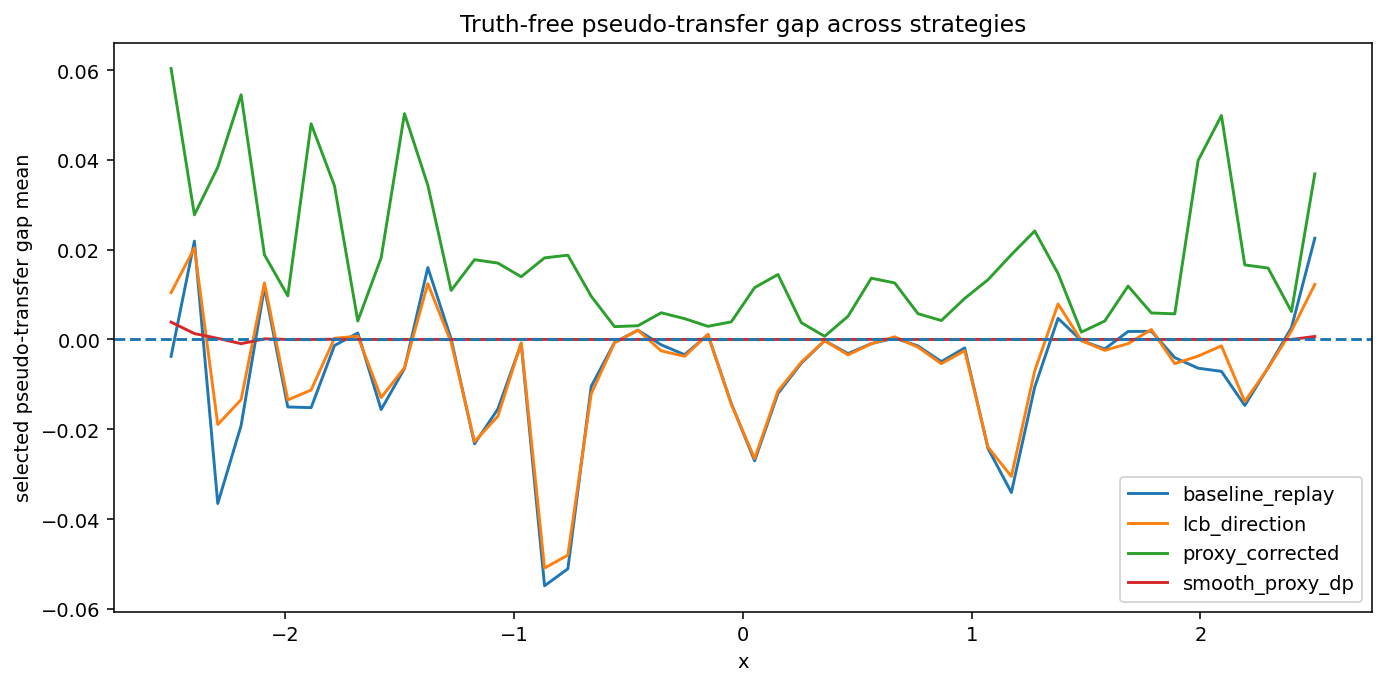

In [11]:
plt.figure(figsize=(10, 5))
for strategy in STRATEGIES:
    df = all_results[strategy]["pointwise_summary"]
    plt.plot(df["x"], df["g_pseudo_mean"], label=strategy)
plt.axhline(0.0, linestyle="--")
plt.xlabel("x")
plt.ylabel("selected pseudo-transfer gap mean")
plt.title("Truth-free pseudo-transfer gap across strategies")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "compare_g_pseudo_mean.png", bbox_inches="tight")
plt.show()


## 11. Plot truth-free direction instability for each strategy

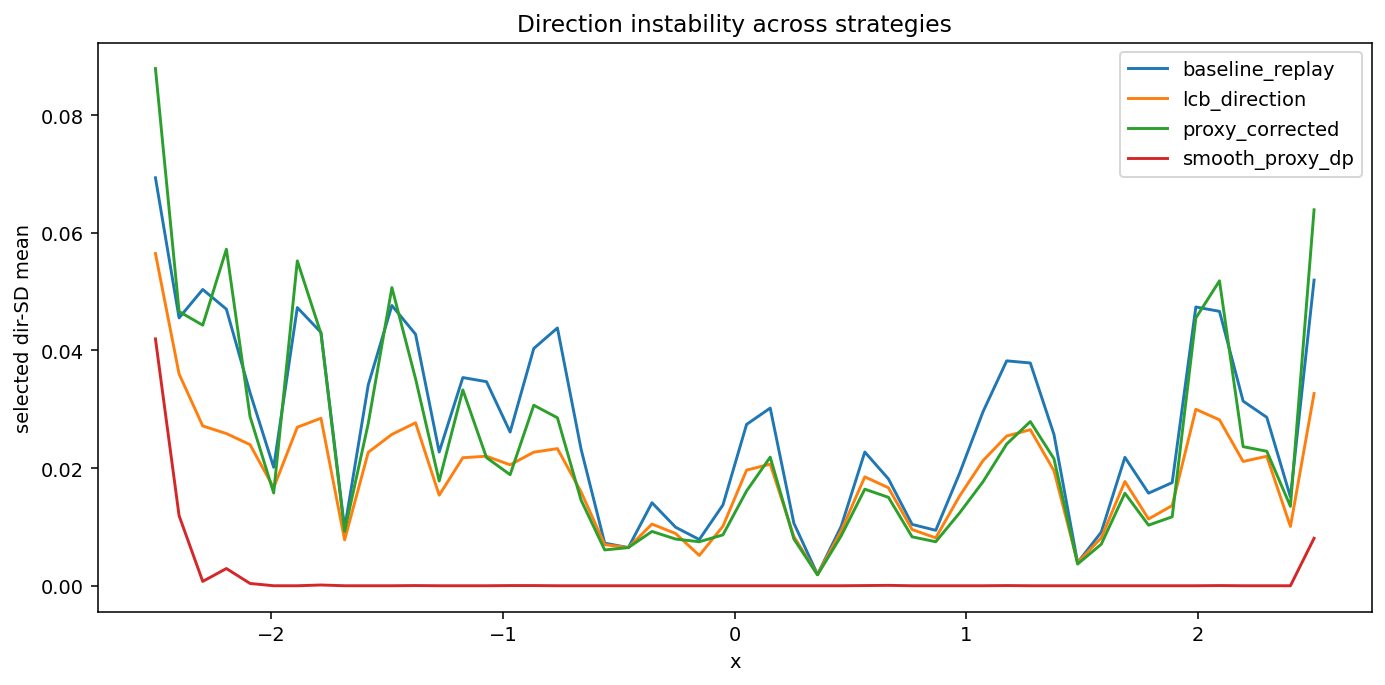

In [12]:
plt.figure(figsize=(10, 5))
for strategy in STRATEGIES:
    df = all_results[strategy]["pointwise_summary"]
    plt.plot(df["x"], df["dir_sd_mean"], label=strategy)
plt.xlabel("x")
plt.ylabel("selected dir-SD mean")
plt.title("Direction instability across strategies")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "compare_dir_sd_mean.png", bbox_inches="tight")
plt.show()


## 12. Optional offline comparison

In [13]:
if "offline_undercovered_points_nominal_095" in overall_compare.columns:
    display_cols = [
        "strategy",
        "offline_mean_coverage",
        "offline_min_pointwise_coverage",
        "offline_undercovered_points_nominal_095",
        "mean_alpha_star",
        "mean_g_pseudo",
        "mean_dir_sd",
    ]
    offline_compare = overall_compare[display_cols].copy()
    offline_compare.to_csv(OUT_DIR / "offline_compare.csv", index=False)
    offline_compare
else:
    print("No offline evaluation columns found. This is expected if deploy_final files do not include true_f.")


## 13. Save run metadata

In [14]:
meta = {
    "root": str(ROOT),
    "out_dir": str(OUT_DIR),
    "strategies": STRATEGIES,
    "nominal": NOMINAL,
    "params": {
        "LCB_DELTA": LCB_DELTA,
        "PROXY_LAMBDA": PROXY_LAMBDA,
        "PROXY_TAU": PROXY_TAU,
        "ROBUST_Q": ROBUST_Q,
        "SMOOTH_PROXY_LAMBDA": SMOOTH_PROXY_LAMBDA,
        "SMOOTH_PENALTY": SMOOTH_PENALTY,
        "SMOOTH_INSTABILITY_PENALTY": SMOOTH_INSTABILITY_PENALTY,
        "FALLBACK": FALLBACK,
    },
    "notes": [
        "Selection is truth-free.",
        "true_f / offline_hit are used only for offline evaluation if present.",
        "This notebook does not retrain SVGP and does not rerun the formal experiment."
    ],
}
import json
with open(OUT_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)
print("Saved run_metadata.json")


Saved run_metadata.json


## 14. Quick summary

In [15]:
print("Saved outputs to:", OUT_DIR)
print()
print("Main files:")
for p in sorted(OUT_DIR.glob("*")):
    print(" ", p.name)


Saved outputs to: C:\Users\yangy\26 spring\with reference\more_cross\truthfree_nextstep_notebook

Main files:
  baseline_replay
  compare_dir_sd_mean.png
  compare_g_pseudo_mean.png
  lcb_direction
  offline_compare.csv
  overall_compare.csv
  pointwise_compare.csv
  proxy_corrected
  run_metadata.json
  smooth_proxy_dp
